In [3]:
#read in adata objects
import anndata as ad
import pandas as pd
import scanpy as sc
import os
import matplotlib.pyplot as plt

In [ ]:
adata = ad.read_h5ad('../data/cluster_adata/250311_all_tissues_20um_RMS.h5ad')

In [ ]:
# set organ column based on image and x coordinates
adata.obs.loc[adata.obs['x']<7500, 'organ'] = 'spleen'
adata.obs.loc[(adata.obs['x']>=7500) & (adata.obs['x']<20000), 'organ'] = 'pancreas'
adata.obs.loc[(adata.obs['x']>=20000) & (adata.obs['x']<28000), 'organ'] = 'RPG'
adata.obs.loc[(adata.obs['x']>=28000) & (adata.obs['x']<43000), 'organ'] = 'parotid'
adata.obs.loc[adata.obs['x']>=43000, 'organ'] = 'SMG' 
adata.obs['organ'][adata.obs['leiden'] == '14'] = 'SLG'


In [ ]:
all_organs = adata.copy()
all_organs

AnnData object with n_obs × n_vars = 511780 × 934
    obs: 'name', 'spotId', 'x', 'y', 'leiden', 'organ'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'name', 'organ_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

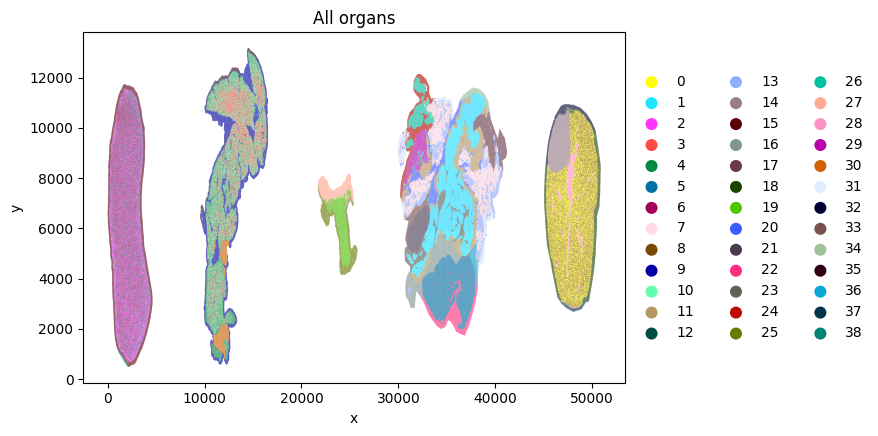

In [12]:
#plot all_organs on x y coordinates colored by leiden
sc.pl.scatter(all_organs, x='x', y='y', color='leiden', title='All organs', show=True)

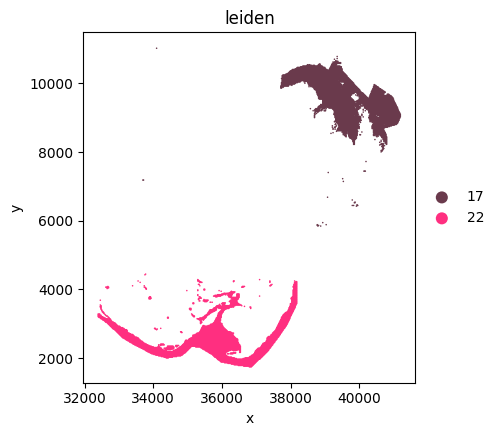

In [ ]:
#plot clusters on x and y coordinates
#mask = (all_organs.obs['x'] < 50000) & (all_organs.obs['x'] > 45000) #& (all_organs.obs['y'] < 3500) & (all_organs.obs['y'] > 1500)

mask = (
    (all_organs.obs['x'] > 29000)
    & (all_organs.obs['x'] < 41000)
    # exclude leiden 18 and 32
    #& (~all_organs.obs['leiden'].isin([ '1','26' , '29', '13',  '5','7', '16', '24', '23', '17', '21', '20',
     #                                  '11', '36', '27','32' , '37'])) #'31' -> border, 22 potentially border
    #(all_organs.obs['leiden'].isin([ '27','32' ,'33','34','36' ,'37']))
)
mask = all_organs.obs['leiden'].isin(['17', '22']) 

# subset the AnnData and plot the filtered spots
subset = all_organs[mask]
sc.pl.scatter(subset, x='x', y='y', color='leiden', show=False, size=5)
plt.gca().set_aspect('equal', adjustable='box')


In [ ]:
#make new column assigning border or tissue based on leiden clusters
all_organs.obs['border_or_tissue'] = 'tissue'
all_organs.obs.loc[all_organs.obs['leiden'].isin(['18', '32', '37']), 'border_or_tissue'] = 'border' #SMG
all_organs.obs.loc[all_organs.obs['leiden'].isin(['38', '15' ]), 'border_or_tissue'] = 'border' #spleen
all_organs.obs.loc[all_organs.obs['leiden'].isin(['35', '9']), 'border_or_tissue'] = 'border' #pancreas
all_organs.obs.loc[all_organs.obs['leiden'].isin(['31', '34', '33', '24', '22']), 'border_or_tissue'] = 'border' #parotid
all_organs.obs.loc[all_organs.obs['leiden'].isin([ '16', '26', '7', '13', '20', '17']), 'border_or_tissue'] = 'connective'  #parotid


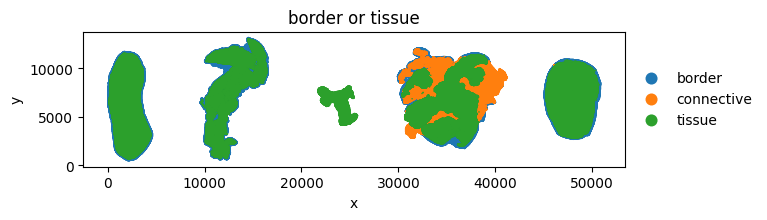

In [16]:
sc.pl.scatter(all_organs, x='x', y='y', color='border_or_tissue', show=False, size=5)
plt.gca().set_aspect('equal', adjustable='box')

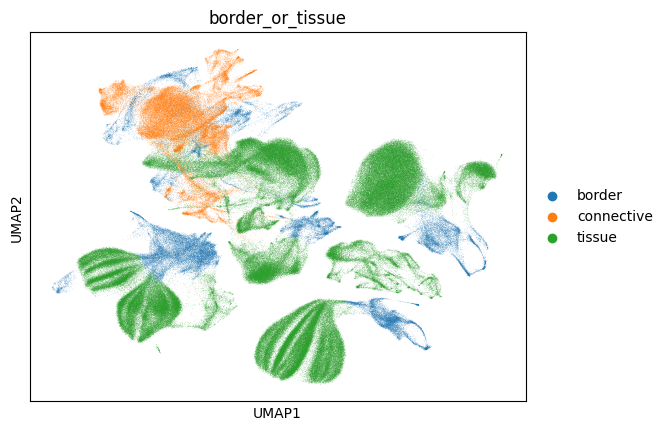

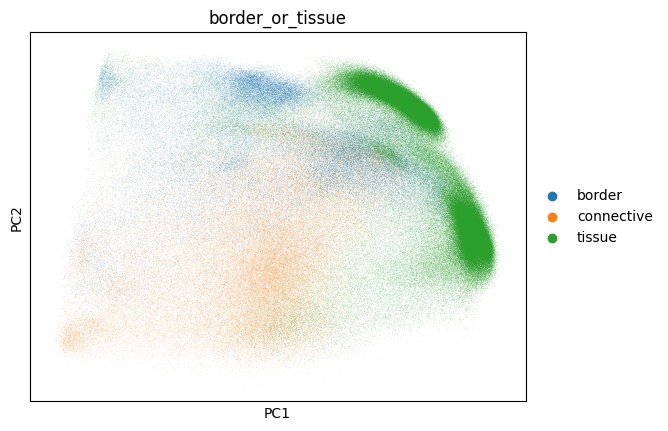

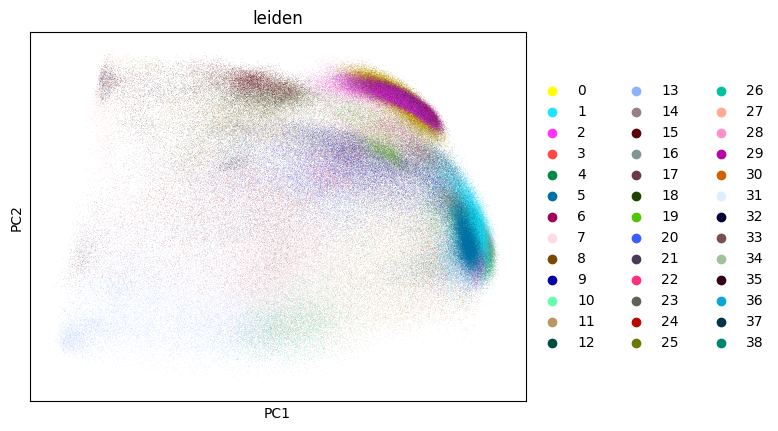

In [17]:
sc.pl.umap(all_organs, color='border_or_tissue', show=True)

sc.pl.pca(all_organs, color='border_or_tissue', show=True)
sc.pl.pca(all_organs, color='leiden', show=True)

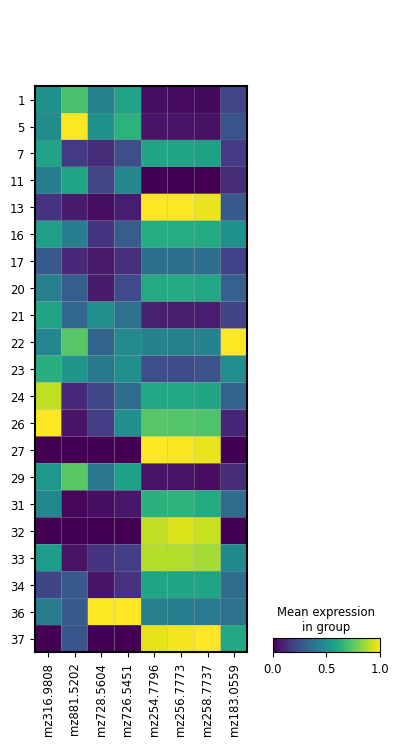

In [18]:
#plot heatmap of mean expression of mz183.0559 per leiden cluster
sc.pl.matrixplot(all_organs[all_organs.obs['organ'] == 'parotid'], var_names=['mz316.9808', 'mz881.5202', 'mz728.5604', 'mz726.5451', 'mz254.7796','mz256.7773', 'mz258.7737','mz183.0559',], groupby='leiden', use_raw=False, standard_scale='var', show=True)

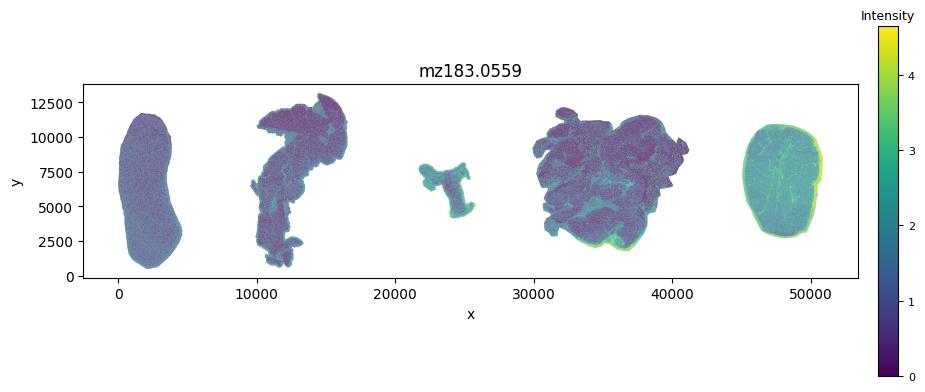

<Figure size 640x480 with 0 Axes>

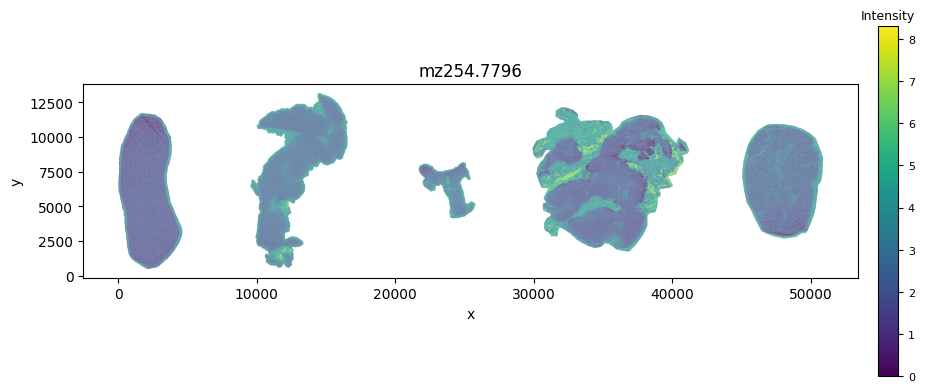

<Figure size 640x480 with 0 Axes>

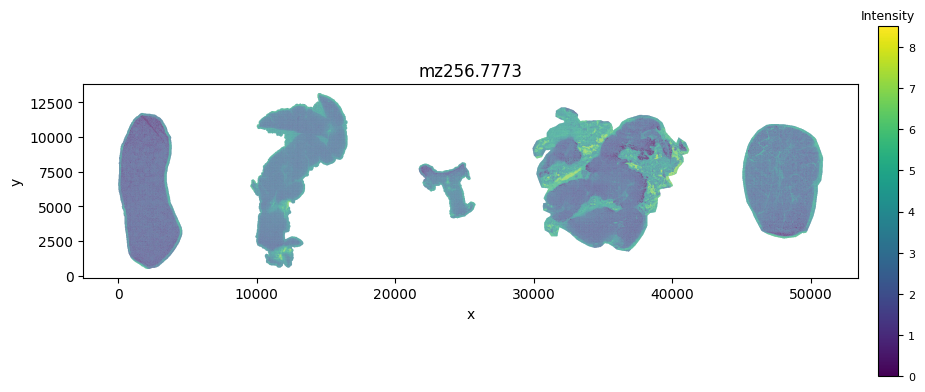

<Figure size 640x480 with 0 Axes>

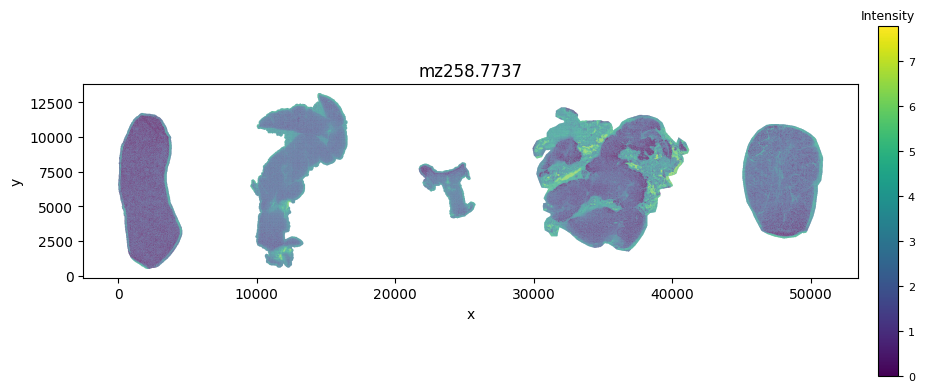

<Figure size 640x480 with 0 Axes>

In [154]:
connective_tissue_mzs = ['mz183.0559', 'mz254.7796', 'mz256.7773', 'mz258.7737']
for i, mz in enumerate(connective_tissue_mzs):
    fig, ax = plt.subplots()
    sc.pl.scatter(all_organs, x='x', y='y', color=mz, title=f'{mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.gcf().set_size_inches(10, 10)
    plt.show()
    plt.tight_layout()

In [19]:
tissue = all_organs.obs['border_or_tissue'] == 'tissue'
clean_all_organs = all_organs[tissue, :].copy()

In [ ]:
clean_all_organs, all_organs, clean_all_organs.obs

In [ ]:
# save clean_all_organs.obs to csv
clean_all_organs.obs.to_csv('../data/background_removed/clean_all_organs_obs.csv')

# save clean_all_organs to h5ad
clean_all_organs.write('../data/background_removed/clean_all_organs_no_border_processed.h5ad')

In [ ]:
# subsetting all_organs csv to only include tissue spots
raw = pd.read_csv('../data/raw/250311_all_tissues_20um_RMS.csv')
#subset raw to only include tissue by spotId
clean_raw = raw[raw['spotId'].isin(clean_all_organs.obs['spotId'])].copy()
# save clean_raw to csv
clean_raw.to_csv('../data/background_removed/clean_all_organs_raw.csv', index=False)
clean_raw

,name,spotId,x,y,mz78.9589,mz79.9571,mz80.9644,mz81.9527,mz85.0292,mz87.0084,...,mz911.565,mz912.5705,mz913.5817,mz914.585,mz915.4771,mz919.5095,mz943.5108,mz944.5138,mz945.5108,mz959.4837
264,Regions/250311_all_tissues_20um/smg_export,250730,47396.781250,10846.380859,504.956299,80.826416,10.671685,7.702173,5.243045,56.095943,...,4.036681,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,5.428640,0.000000,0.000000
352,Regions/250311_all_tissues_20um/smg_export,250818,47396.781250,10826.380859,370.923859,135.501907,11.151959,8.317348,13.762786,65.046883,...,3.132992,0.000000,0.000000,0.000000,0.0,2.349744,2.909207,0.000000,2.946504,0.000000
353,Regions/250311_all_tissues_20um/smg_export,250819,47416.781250,10826.380859,440.920807,102.123169,13.242905,9.974624,4.456747,60.908875,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
356,Regions/250311_all_tissues_20um/smg_export,250822,47476.781250,10826.380859,469.715332,111.334068,0.000000,4.187241,7.350933,61.598957,...,0.000000,2.931068,0.000000,3.442842,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
440,Regions/250311_all_tissues_20um/smg_export,250906,47236.781250,10806.380859,515.446960,91.616142,14.129185,0.000000,0.000000,62.329380,...,4.337123,3.889997,3.308733,0.000000,0.0,0.000000,4.113560,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511443,Regions/250311_all_tissues_20um/spleen_export,92549,2136.780273,666.381348,533.743347,147.006485,24.022837,7.541226,3.082891,13.849296,...,2.466313,1.754876,2.703458,3.059177,0.0,1.494017,3.604611,3.154035,0.000000,0.000000
511444,Regions/250311_all_tissues_20um/spleen_export,92550,2156.780273,666.381348,507.373749,148.992599,10.835390,13.897046,4.520726,6.195069,...,2.344080,0.000000,3.827070,3.468282,0.0,0.000000,3.205171,2.080969,0.000000,0.000000
511445,Regions/250311_all_tissues_20um/spleen_export,92551,2176.780273,666.381348,481.793579,152.557541,9.893996,4.101258,3.684181,9.222038,...,1.853676,2.131727,4.726874,1.853676,0.0,0.000000,2.039044,1.784163,1.784163,0.000000
511446,Regions/250311_all_tissues_20um/spleen_export,92552,2196.780273,666.381348,504.901733,159.256561,14.443675,4.864710,5.993122,5.441454,...,1.830535,0.000000,2.632962,1.680080,0.0,0.000000,3.084327,2.031142,0.000000,1.955914
